---
1. Native (T1) (raw)
2. Post-contrast T1-weighted (T1CE)
3. T2-weighted (T2)
4. T2 Fluid Attenuated Inversion Recovery (Flair) Volumes

---
### Mask label description
- label 0: unlabeleld
- label 1: necrotic and non-enhancing tumor core
- label 2: peritumoral edema (ED)
- label 3: missing
- label 4: GD-enhancing tumor (ET)
---

In [39]:
import numpy as numpy
import nibabel as nib

import glob
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
from sklearn.preprocessing import MinMaxScaler

import numpy as np
import plotly.graph_objs as go
from plotly.subplots import make_subplots

from skimage.segmentation import slic
import numpy as np

In [40]:
RAW_DIR = "../data/raw/MICCAI_BraTS2020_TrainingData/"
PROCESSSED_DIR = "../data/processed/"
sample_dir = RAW_DIR + "BraTS20_Training_001/BraTS20_Training_001_flair.nii"

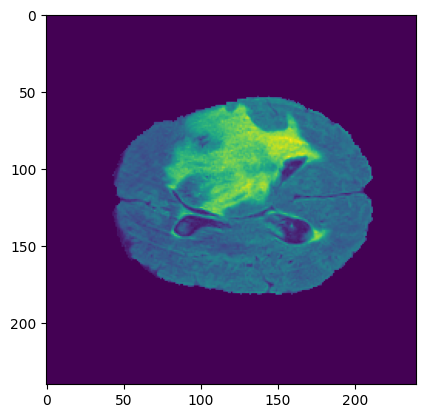

In [41]:
sample_image_raw = nib.load(sample_dir).get_fdata()
sample_image_raw.shape

img = sample_image_raw.reshape(
    -1, 1
)  # reminder: 1-dim is sample, 2-dim is the feature vector
scaler = MinMaxScaler()
img = scaler.fit_transform(img)
sample_image = img.reshape(240, 240, 155)

plt.imshow(sample_image[:, :, 80])

Shape of the image data array: (5, 240, 240, 155)
max: 1091.0, min: 0.0


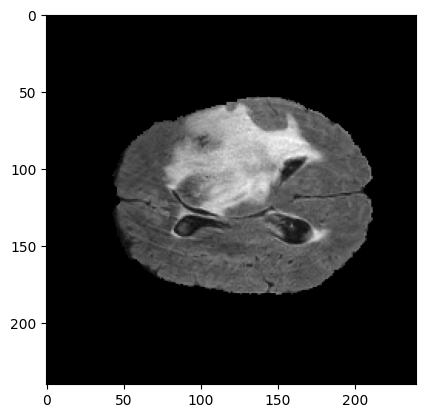

In [42]:
import numpy as np
import os
import nibabel as nib
from sklearn.preprocessing import MinMaxScaler

RAW_DIR = "../data/raw/MICCAI_BraTS2020_TrainingData/"

num_total_samples = 369  # cant allocate memory
num_samples = 5

image_data_list = []

# Iterate over each sample
for i in range(1, num_samples + 1):
    sample_dir = os.path.join(
        RAW_DIR, f"BraTS20_Training_{i:03}", f"BraTS20_Training_{i:03}_flair.nii"
    )
    # print(f"loading img: {i} | directory: {sample_dir}")

    if os.path.exists(sample_dir):
        current_image = nib.load(sample_dir).get_fdata()
        image_data_list.append(current_image)

data_train_raw = np.array(image_data_list)
print("Shape of the image data array:", data_train_raw.shape)
print(f"max: {data_train_raw.max()}, min: {data_train_raw.min()}")
plt.imshow(data_train_raw[0, :, :, 80], cmap="gray")

max: 1.0000000000000009, min: 0.0


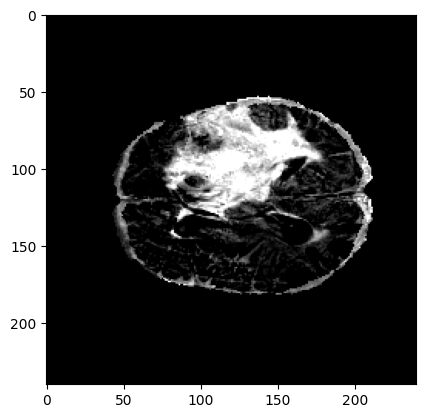

In [43]:
def scale_dataset(dataset):
    scaler = MinMaxScaler()

    data = data_train_raw.reshape(
        num_samples, -1
    )  # reminder: 1-dim is sample, 2-dim is the feature vector
    data = scaler.fit_transform(data)
    data = data.reshape(num_samples, 240, 240, 155)

    return data


data_train = scale_dataset(data_train_raw)
print(f"max: {data_train.max()}, min: {data_train.min()}")
plt.imshow(data_train[0, :, :, 80], cmap="gray")

In [44]:
np.save(PROCESSSED_DIR + " BraTS2020_scaled.npy", data_train)

In [45]:
sample_image.shape

(240, 240, 155)

In [46]:
n_segments = 100

# trade-off between color proximity and spatial proximity
# low: empphasis on color similarity, high: empphasis on proximity
compactness = 0.01

segmented_image = np.zeros_like(sample_image, dtype=np.int32)

segmented_image = slic(
    sample_image, n_segments=n_segments, compactness=compactness, channel_axis=None
)

segmented_image.min(), segmented_image.max(), segmented_image.shape

(1, 54, (240, 240, 155))

In [47]:
sample_image

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

In [48]:
def plot_slic(segmented_image):
    plt.figure(figsize=(8, 8))
    plt.imshow(segmented_image, cmap="viridis")
    plt.colorbar(label="Segment Labels")
    plt.title("SLIC Segmentation Map")
    plt.xlabel("Width (pixels)")
    plt.ylabel("Height (pixels)")
    plt.grid(False)
    plt.show()

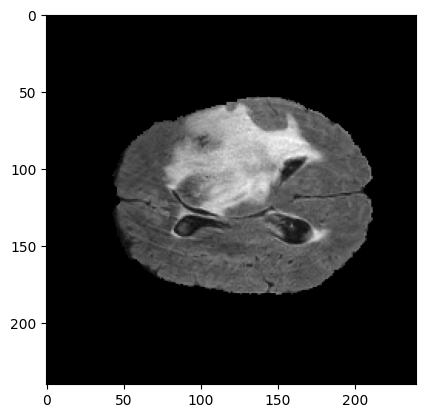

In [49]:
sample_image.shape
plt.imshow(sample_image[:, :, 80], cmap="gray")

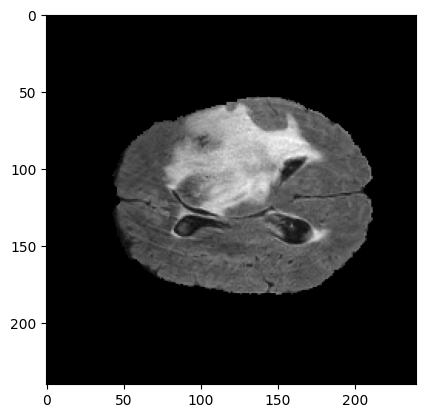

In [50]:
sample_slice = sample_image[:, :, 80]
plt.imshow(sample_slice, cmap="gray")

(240, 240) 1 37


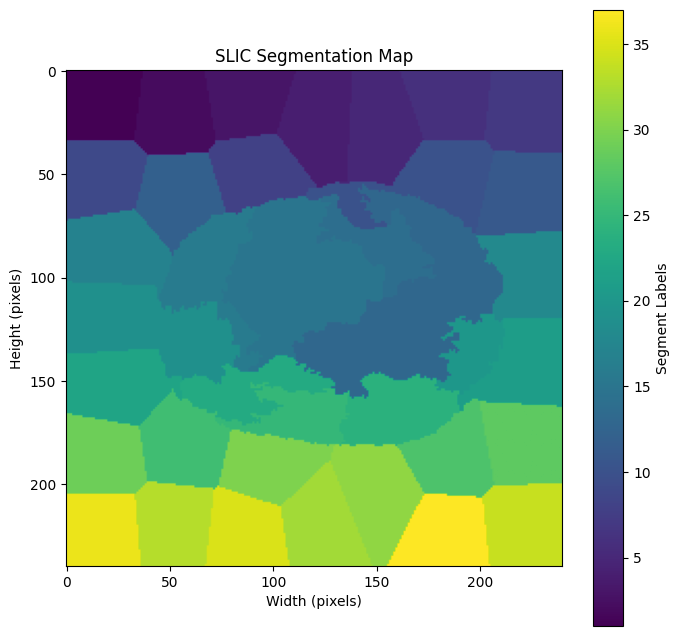

In [51]:
slic_output = slic(sample_slice, n_segments=50, compactness=0.05, channel_axis=None)
print(slic_output.shape, slic_output.min(), slic_output.max())
plot_slic(slic_output)

(240, 155) 1 44


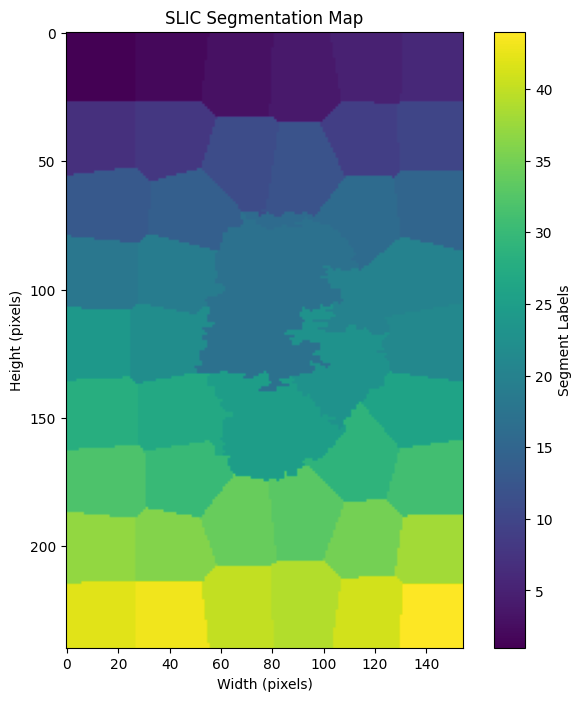

In [52]:
slic_output = slic(sample_image[:, 80, :], n_segments=50, compactness=0.05, channel_axis=None)
print(slic_output.shape, slic_output.min(), slic_output.max())
plot_slic(slic_output)

(240, 155) 1 40


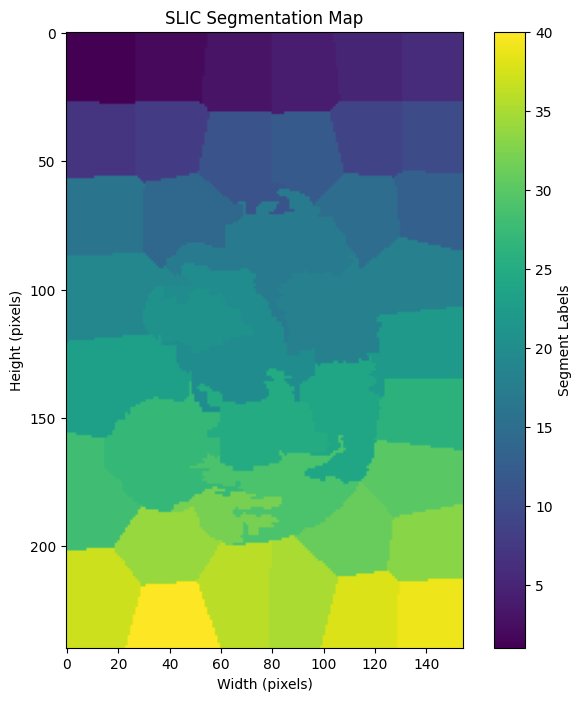

In [53]:
slic_output = slic(sample_image[80, :, :], n_segments=50, compactness=0.05, channel_axis=None)
print(slic_output.shape, slic_output.min(), slic_output.max())
plot_slic(slic_output)

In [54]:
slic_voxel_result = slic(
    sample_image, n_segments=50, compactness=0.001, channel_axis=None
)

In [55]:
sample_image.shape

(240, 240, 155)

(240, 240, 155) 1 27


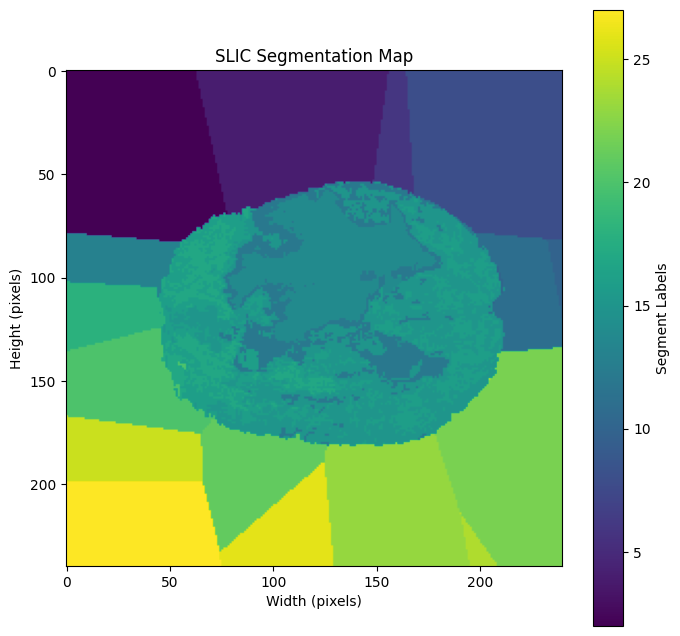

In [56]:
print(slic_voxel_result.shape, slic_voxel_result.min(), slic_voxel_result.max())
plot_slic(slic_voxel_result[:, :, 80])

In [80]:
import torch
import torch.nn as nn


class Encoder(nn.Module):
    def __init__(
        self,
        conv_out_channels: int = 8,
        embedding_size: int = 9,
        dim_0: int = 32,
        dim_1: int = 32,
        dim_2: int = 28,
    ):
        super(Encoder, self).__init__()
        self.conv_out_channels = conv_out_channels
        self.embedding_size = embedding_size
        self._dim_0 = dim_0 // 2
        self._dim_1 = dim_1 // 2
        self._dim_2 = dim_2 // 2

        self.conv1 = nn.Conv3d(1, self.conv_out_channels, kernel_size=3, padding=1)
        self.relu = nn.ReLU(True)
        self.pool = nn.MaxPool3d(2, padding=0, stride=2)
        self.fc = nn.Linear(
            self.conv_out_channels * self._dim_0 * self._dim_1 * self._dim_2,
            self.embedding_size,
        )

    def forward(self, x):
        x = self.conv1(x)  # torch.Size([batch, channels, dim0, dim1, dim2])
        x = self.relu(x)
        x = self.pool(x)  # torch.Size([batch, channels, dim0/2, dim1/2, dim2/2])
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x


class Decoder(nn.Module):
    def __init__(
        self, conv_in_channels, embedding_size=9, dim_0=32, dim_1=32, dim_2=28
    ):
        super(Decoder, self).__init__()
        self.conv_in_channels = conv_in_channels
        self.embedding_size = embedding_size
        self._dim_0 = dim_0 // 2
        self._dim_1 = dim_1 // 2
        self._dim_2 = dim_2 // 2

        self.fc = nn.Linear(
            self.embedding_size,
            self.conv_in_channels * self._dim_0 * self._dim_1 * self._dim_2,
        )
        self.conv_transpose = nn.ConvTranspose3d(
            conv_in_channels, 1, kernel_size=3, stride=1, padding=1
        )
        self.upsample = nn.Upsample(scale_factor=2, mode="nearest")
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.fc(x)
        x = x.view(
            x.size(0), self.conv_in_channels, self._dim_0, self._dim_1, self._dim_2
        )
        x = self.upsample(x)
        x = self.conv_transpose(x)
        x = self.sigmoid(x)
        # print("Decoder output shape: {x.shape}")

        return x


class Autoencoder(nn.Module):
    def __init__(
        self,
        conv_in_channels,
        conv_out_channels,
        embedding_size=9,
        dim_0=32,
        dim_1=32,
        dim_2=28,
    ):
        super(Autoencoder, self).__init__()
        self.conv_in_channels = conv_in_channels
        self.conv_out_channels = conv_out_channels
        self.embedding_size = embedding_size
        self._dim_0 = dim_0 // 2
        self._dim_1 = dim_1 // 2
        self._dim_2 = dim_2 // 2

        self.encoder = Encoder(
            self.conv_out_channels,
            self.embedding_size,
            self.dim_0,
            self.dim_1,
            self.dim_2,
        )
        self.decoder = Decoder(
            self.conv_out_channels,
            self.embedding_size,
            self.dim_0,
            self.dim_1,
            self.dim_2,
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        # x = self.decoder(x.view(batch_size, 16, 16, 14).unsqueeze(1))  # Reshape for decoder input
        return x

In [74]:
x = torch.randn(1, 1, 32, 32, 28)  # Example: Batch size 1, 1 channel, 32x32x32 volume

encoder = Encoder(conv_out_channels=8, embedding_size=16)
encoder_output = encoder(x)
print(encoder_output.shape)

decoder = Decoder(conv_in_channels=8, embedding_size=16)
print(decoder(encoder_output).shape)


torch.Size([1, 28672])
torch.Size([1, 16])
torch.Size([1, 1, 32, 32, 28])


In [75]:
medical_images_tensor = (
    torch.tensor(sample_image, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
)  # add channel dimension
x = medical_images_tensor[:, :, : ,:, :154]
x.shape



torch.Size([1, 1, 240, 240, 154])

In [81]:
encoder = Encoder(
    conv_out_channels=8, embedding_size=16, dim_0=240, dim_1=240, dim_2=154
)
encoder_output = encoder(x)
print(encoder_output.shape)

decoder = Decoder(
    conv_in_channels=8, embedding_size=16, dim_0=240, dim_1=240, dim_2=154
)
print(decoder(encoder_output).shape)

autoencoder = Autoencoder(
    conv_in_channels=8,
    conv_out_channels=8,
    embedding_size=16,
    dim_0=240,
    dim_1=240,
    dim_2=154,
)
autoencoder(x)

torch.Size([1, 16])
torch.Size([1, 1, 240, 240, 154])


TypeError: Autoencoder.__init__() missing 1 required positional argument: 'conv_in_channels'

In [38]:
# model = Autoencoder()


# for name, layer in model.named_modules():
#     print(f"Layer name: {name}\nLayer: {layer}\n")

In [61]:
autoencoder = Autoencoder(4)

# x = torch.randn(1, 1, 32, 32, 28)  # Example: Batch size 1, 1 channel, 32x32x32 volume

# Forward pass through the autoencoder
output = autoencoder(x)

# Print the output shape
print("Output shape:", output.shape)

Encoder conv shape: torch.Size([1, 8, 32, 32, 28])
Encoder output shape: torch.Size([1, 8, 16, 16, 14])
torch.Size([1, 8, 16, 16, 14])
torch.Size([1, 28672])


RuntimeError: Expected 4D (unbatched) or 5D (batched) input to conv_transpose3d, but got input of size: [1, 4]

77.0

In [26]:
medical_images_tensor = (
    torch.tensor(sample_image, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
)  # add channel dimension
medical_images_tensor[:, :, : ,:, :154]

torch.Size([1, 1, 240, 240, 154])

In [27]:
# Create a DataLoader for the dataset
dataset = TensorDataset(medical_images_tensor)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# Initialize the autoencoder model
autoencoder = Autoencoder()

# Define the loss function and optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(autoencoder.parameters(), lr=0.001)

# Training the autoencoder
num_epochs = 10
for epoch in range(num_epochs):
    running_loss = 0.0
    for data in dataloader:
        inputs = data[0]

        # Forward pass
        print(inputs.shape)
        outputs = autoencoder(inputs)
        print(outputs.shape)
        loss = criterion(outputs, inputs)

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {running_loss / len(dataloader)}")

# Save the trained model
torch.save(autoencoder.state_dict(), "autoencoder_model.pth")

torch.Size([1, 1, 240, 240, 155])
torch.Size([1, 1, 240, 240, 155])
torch.Size([1, 8, 238, 238, 153])
torch.Size([1, 8, 238, 238, 153])
torch.Size([1, 8, 119, 119, 76])
torch.Size([1, 1, 240, 240, 154])
torch.Size([1, 1, 240, 240, 154])
torch.Size([1, 1, 240, 240, 154])


ValueError: Using a target size (torch.Size([1, 1, 240, 240, 155])) that is different to the input size (torch.Size([1, 1, 240, 240, 154])) is deprecated. Please ensure they have the same size.